# 05 — Analysis & Visualization

Applies the trained sentiment model to all articles, then produces:
- Topic-level sentiment
- Entity-level sentiment (organizations AND technologies)
- Sentiment over time (overall + by topic)
- **Explicit answers to the three task questions**

In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
from pathlib import Path

for d in ["figures", "outputs"]:
    Path(d).mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 150,
})

LABEL_MAP = {0: "negative", 1: "neutral", 2: "positive"}
SCORE_MAP  = {"negative": -1, "neutral": 0, "positive": 1}

In [2]:
# ── load data ─────────────────────────────────────────────────────────────────
df = pd.read_parquet("data/news_with_topics_labeled.parquet")
print(f"Articles for sentiment scoring: {len(df):,}")
print(f"Note: this is a sample of the full corpus — see 02_topic_modeling for sampling details.")
df.head(2)

Articles for sentiment scoring: 23,237
Note: this is a sample of the full corpus — see 02_topic_modeling for sampling details.


,url,date,language,title,text,article_text,text_len,is_ai_related,topic,topic_prob,topic_label
0,https://www.novinite.com/articles/215893/Top+1...,2022-07-12,en,Top 13 Ways Artificial Intelligence Has Change...,\nTop 13 Ways Artificial Intelligence Has Chan...,Top 13 Ways Artificial Intelligence Has Change...,18885,True,-1,0.0,Other / Mixed Topic
1,https://www.dnews.com/northwest/komodo-health-...,2024-10-17,en,Komodo Health Unveils New Generative AI Offeri...,Komodo Health Unveils New Generative AI Offeri...,Komodo Health Unveils New Generative AI Offeri...,7325,True,-1,0.0,Other / Mixed Topic


In [3]:
# ── load sentiment model ──────────────────────────────────────────────────────
MODEL_PATH = "models/sentiment_distilbert_final"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_PATH)
model      = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()
print(f"Model on: {device}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model on: cpu


In [4]:
# ── predict in batches (faster than one-by-one) ───────────────────────────────
BATCH_SIZE = 32
MAX_CHARS  = 2000

all_labels, all_scores, all_confs = [], [], []

texts = df["article_text"].tolist()

for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Scoring sentiment"):
    batch_texts = [t[:MAX_CHARS] for t in texts[i: i + BATCH_SIZE]]
    inputs = tokenizer(
        batch_texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=256,
    ).to(device)

    with torch.no_grad():
        logits = model(**inputs).logits
        probs  = torch.softmax(logits, dim=1).cpu().numpy()

    for prob_row in probs:
        pred_id = prob_row.argmax()
        label   = LABEL_MAP[pred_id]
        all_labels.append(label)
        all_scores.append(SCORE_MAP[label])
        all_confs.append(float(prob_row.max()))

df["sentiment"]            = all_labels
df["sentiment_score"]      = all_scores
df["sentiment_confidence"] = all_confs

print(df["sentiment"].value_counts())

Scoring sentiment: 100%|██████████| 727/727 [1:08:06<00:00,  5.62s/it]


sentiment
neutral     18785
positive     3863
negative      589
Name: count, dtype: int64


In [5]:
df.to_parquet("data/news_topics_sentiment.parquet", index=False)
print("Saved data/news_topics_sentiment.parquet")

Saved data/news_topics_sentiment.parquet


## Topic-Level Sentiment

In [6]:
topic_sentiment = (
    df.groupby("topic_label")
    .agg(
        articles          = ("article_text", "count"),
        avg_sentiment     = ("sentiment_score", "mean"),
        positive_share    = ("sentiment", lambda x: (x == "positive").mean()),
        negative_share    = ("sentiment", lambda x: (x == "negative").mean()),
        neutral_share     = ("sentiment", lambda x: (x == "neutral").mean()),
    )
    .reset_index()
    .sort_values("avg_sentiment", ascending=False)
)

topic_sentiment.to_csv("outputs/topic_sentiment.csv", index=False)
topic_sentiment

,topic_label,articles,avg_sentiment,positive_share,negative_share,neutral_share
6,AI in Banking & Financial Services,225,0.386667,0.448889,0.062222,0.488889
10,AI in Science & Research,134,0.373134,0.373134,0.000000,0.626866
13,Autonomous Vehicles & Automotive AI,117,0.358974,0.367521,0.008547,0.623932
2,AI Chips & Semiconductor Industry,585,0.311111,0.347009,0.035897,0.617094
1,AI & Energy / Power Grid,117,0.307692,0.341880,0.034188,0.623932
16,Crypto & AI Investment,323,0.297214,0.318885,0.021672,0.659443
19,Enterprise AI & Data Security,768,0.283854,0.315104,0.031250,0.653646
12,Apple AI & Siri Intelligence,139,0.258993,0.323741,0.064748,0.611511
4,AI Ethics & Human Intelligence,309,0.242718,0.258900,0.016181,0.724919
25,Middle East AI Adoption (UAE/Saudi),337,0.237389,0.240356,0.002967,0.756677


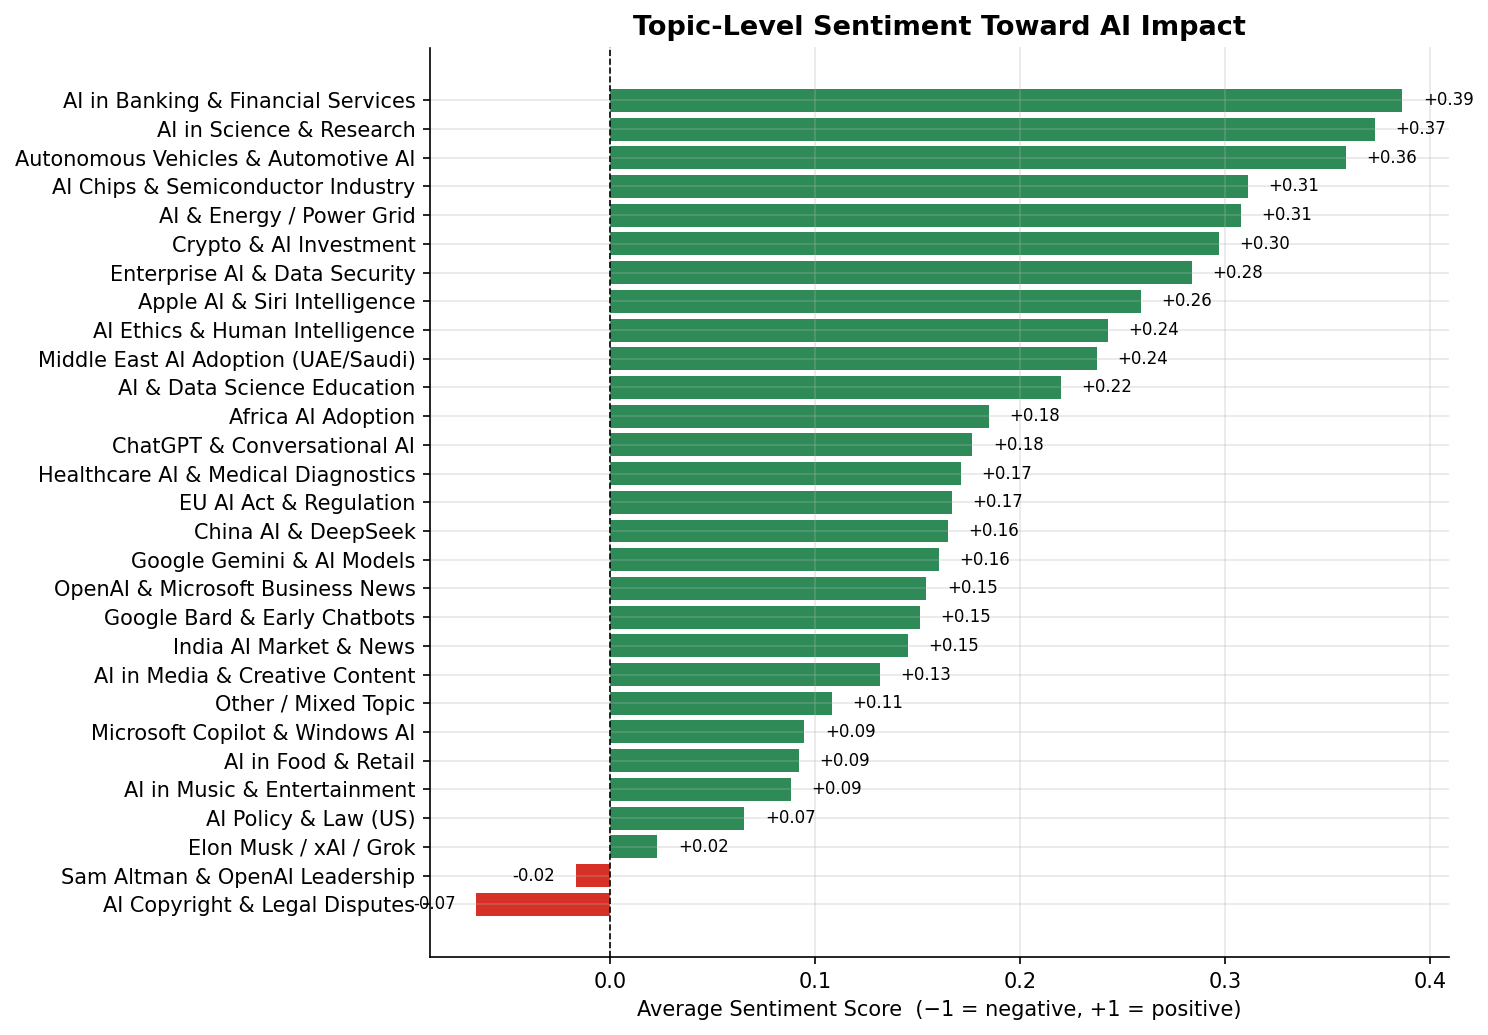

In [7]:
# ── figure: topic-level average sentiment ─────────────────────────────────────
plot_df = topic_sentiment[topic_sentiment["articles"] >= 50].sort_values("avg_sentiment")

colors = ["#d73027" if v < 0 else "#2E8B57" for v in plot_df["avg_sentiment"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(plot_df["topic_label"], plot_df["avg_sentiment"], color=colors, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
for bar, val in zip(bars, plot_df["avg_sentiment"]):
    ax.text(
        val + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height()/2,
        f"{val:+.2f}", va="center",
        ha="left" if val >= 0 else "right",
        fontsize=8
    )
ax.set_xlabel("Average Sentiment Score  (−1 = negative, +1 = positive)")
ax.set_title("Topic-Level Sentiment Toward AI Impact", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/topic_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

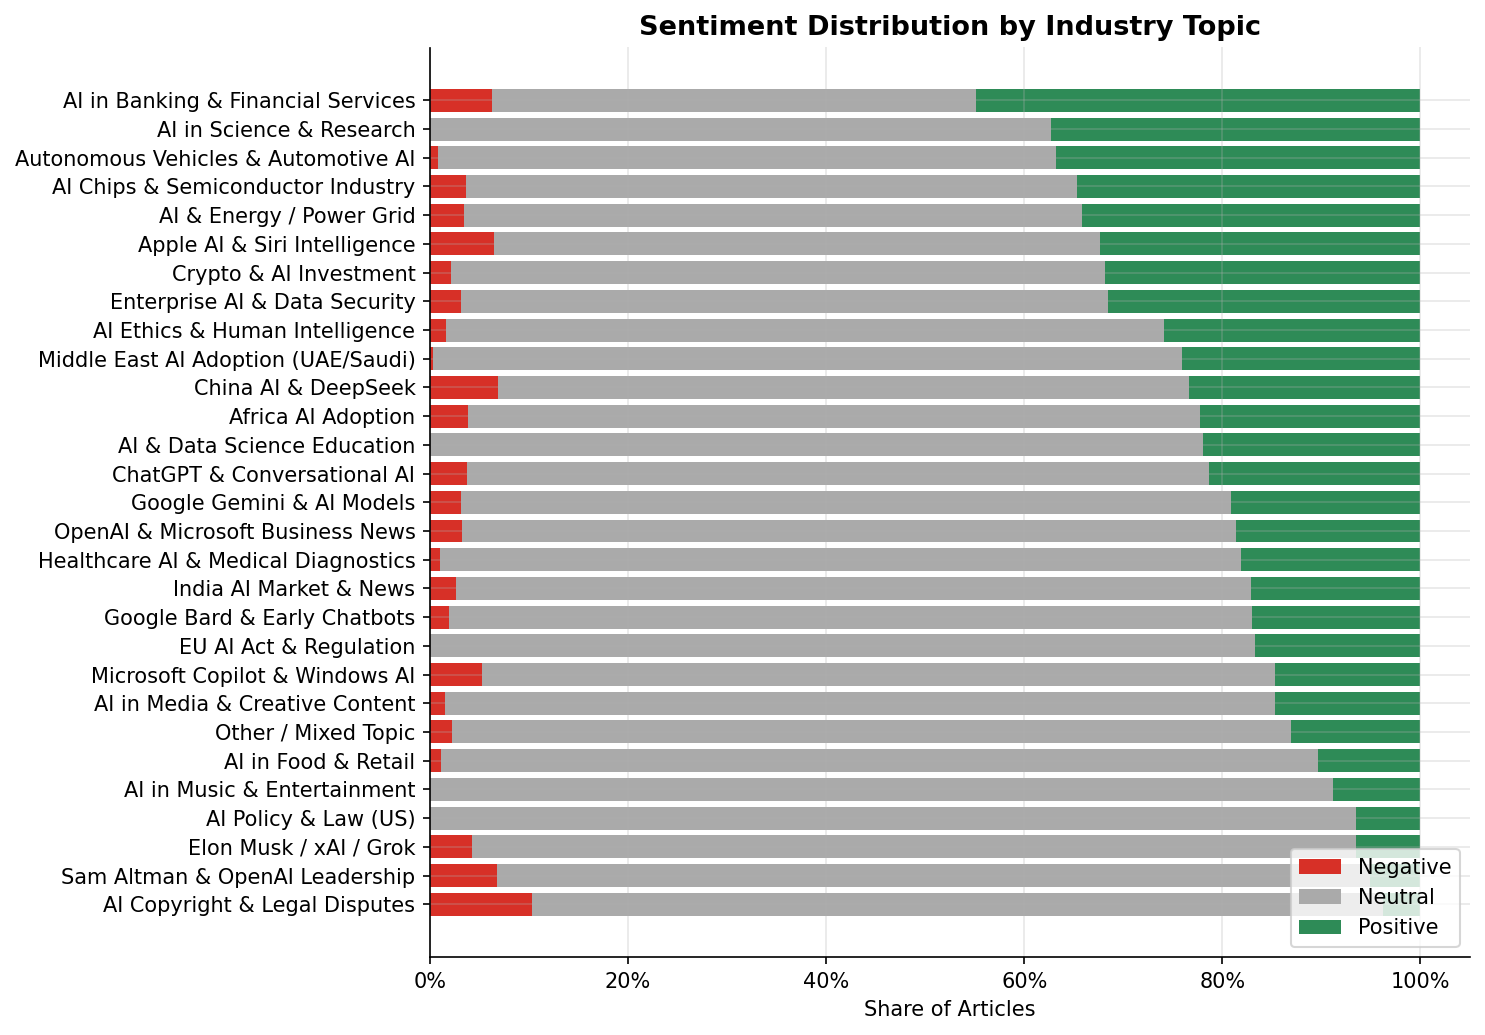

In [8]:
# ── figure: stacked sentiment share by topic ──────────────────────────────────
plot_stack = topic_sentiment[topic_sentiment["articles"] >= 50].sort_values("positive_share")

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_stack["topic_label"], plot_stack["negative_share"], color="#d73027", label="Negative")
ax.barh(plot_stack["topic_label"], plot_stack["neutral_share"],
        left=plot_stack["negative_share"], color="#aaaaaa", label="Neutral")
ax.barh(plot_stack["topic_label"], plot_stack["positive_share"],
        left=plot_stack["negative_share"] + plot_stack["neutral_share"],
        color="#2E8B57", label="Positive")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.set_xlabel("Share of Articles")
ax.set_title("Sentiment Distribution by Industry Topic", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig("figures/topic_sentiment_stacked.png", dpi=300, bbox_inches="tight")
plt.show()

## Entity-Level Sentiment — Organizations

In [9]:
entities_all = pd.read_csv("outputs/entities_all.csv")

# Align article IDs (df was reset_index'd after parquet load)
df_indexed = df.reset_index().rename(columns={"index": "article_id"})

entity_with_sent = entities_all.merge(
    df_indexed[["article_id", "sentiment", "sentiment_score"]],
    on="article_id",
    how="left"
)

# ── organizations ─────────────────────────────────────────────────────────────
org_sent = (
    entity_with_sent[entity_with_sent["entity_type"] == "ORG"]
    .groupby("entity")
    .agg(
        mentions        = ("article_id", "count"),
        avg_sentiment   = ("sentiment_score", "mean"),
        positive_share  = ("sentiment", lambda x: (x == "positive").mean()),
        negative_share  = ("sentiment", lambda x: (x == "negative").mean()),
    )
    .reset_index()
    .query("mentions >= 20")
    .sort_values("mentions", ascending=False)
)

org_sent.to_csv("outputs/entity_sentiment.csv", index=False)
org_sent.head(20)

,entity,mentions,avg_sentiment,positive_share,negative_share
59769,OpenAI,2896,0.119130,0.160221,0.041091
35328,Google,2696,0.142433,0.175445,0.033012
52112,Microsoft,2597,0.144397,0.187524,0.043127
8172,Apple,945,0.134392,0.190476,0.056085
51694,Meta,871,0.113662,0.159587,0.045924
7141,Amazon,760,0.148684,0.196053,0.047368
68495,Reuters,634,0.130915,0.182965,0.052050
9070,Artificial Intelligence,559,0.203936,0.207513,0.003578
9104,Artificial Intelligence AI,511,0.313112,0.328767,0.015656
90154,WhatsApp,477,0.111111,0.129979,0.018868


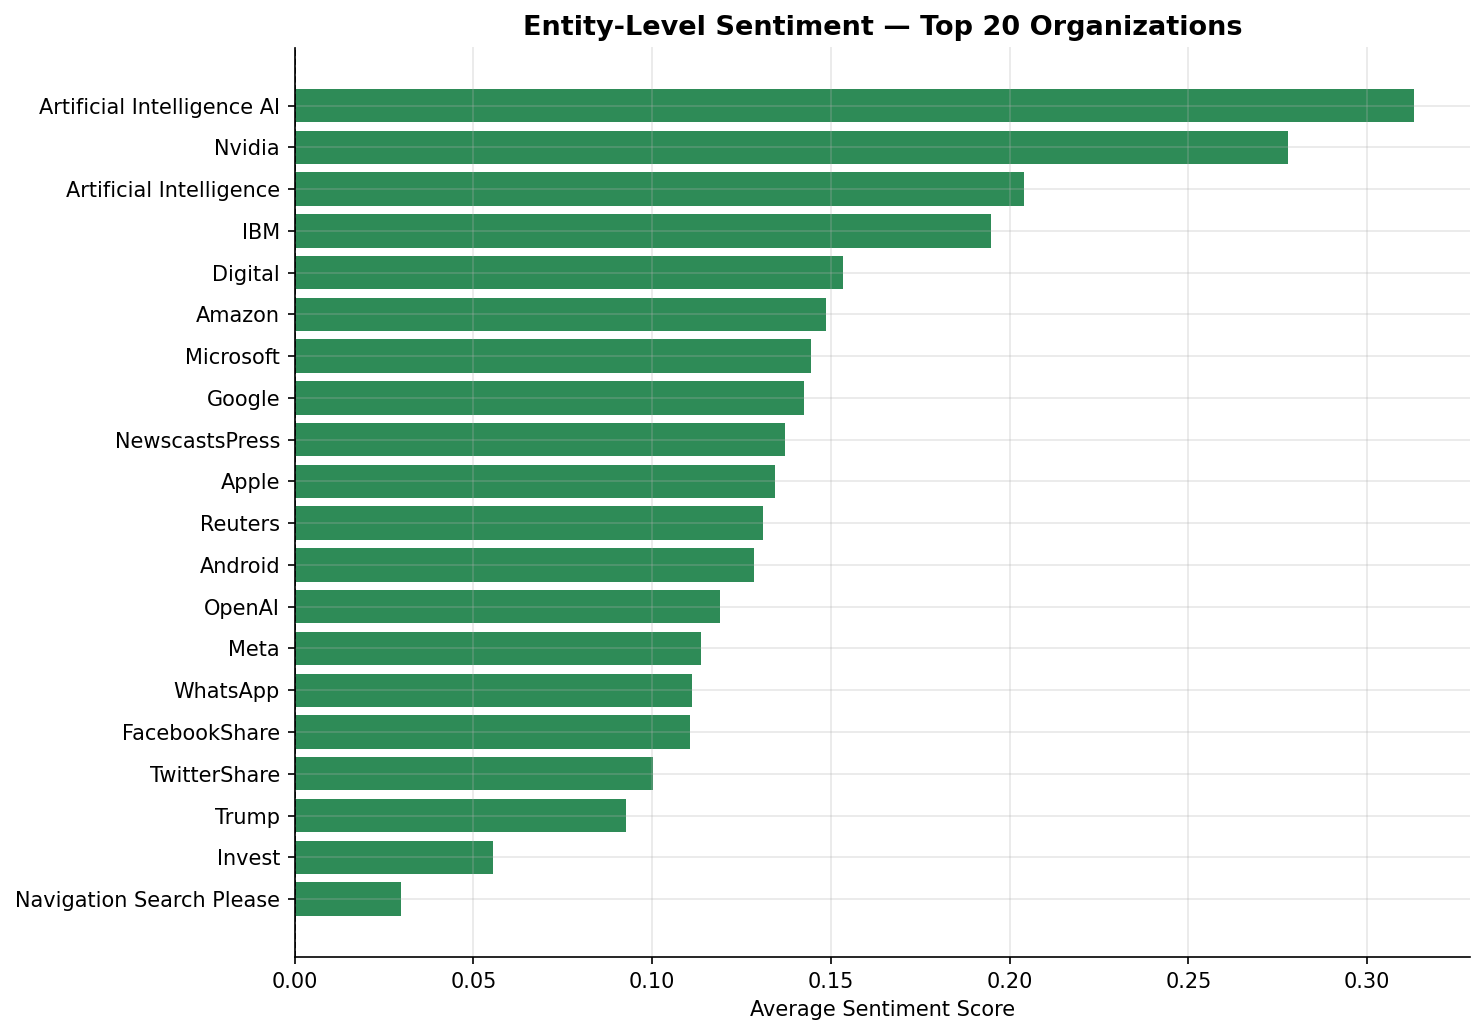

In [10]:
# ── figure: org-level sentiment (top 20 by mentions) ─────────────────────────
top20_orgs = org_sent.head(20).sort_values("avg_sentiment")
colors_org = ["#d73027" if v < 0 else "#2E8B57" for v in top20_orgs["avg_sentiment"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20_orgs["entity"], top20_orgs["avg_sentiment"], color=colors_org, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Average Sentiment Score")
ax.set_title("Entity-Level Sentiment — Top 20 Organizations", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/entity_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

## Entity-Level Sentiment — Technologies

In [11]:
# ── technology-level sentiment ────────────────────────────────────────────────
tech_sent = (
    entity_with_sent[entity_with_sent["entity_type"] == "TECHNOLOGY"]
    .groupby("entity")
    .agg(
        articles        = ("article_id", "count"),
        avg_sentiment   = ("sentiment_score", "mean"),
        positive_share  = ("sentiment", lambda x: (x == "positive").mean()),
        negative_share  = ("sentiment", lambda x: (x == "negative").mean()),
    )
    .reset_index()
    .sort_values("avg_sentiment", ascending=False)
)

tech_sent.to_csv("outputs/technology_sentiment.csv", index=False)
tech_sent

,entity,articles,avg_sentiment,positive_share,negative_share
10,Natural Language Processing,1114,0.252244,0.256732,0.004488
11,Predictive Analytics,955,0.233508,0.250262,0.016754
1,AI in Drug Discovery,341,0.222874,0.225806,0.002933
3,Autonomous Vehicles,763,0.211009,0.230668,0.019659
6,Computer Vision,1219,0.199344,0.214110,0.014766
2,Automation / RPA,4663,0.194939,0.219601,0.024662
5,Cloud AI Platform,2357,0.182011,0.203224,0.021213
7,Deep Learning / Neural Network,1426,0.180224,0.192146,0.011921
14,Robotics,1955,0.178005,0.197442,0.019437
13,Reinforcement Learning,238,0.172269,0.197479,0.025210


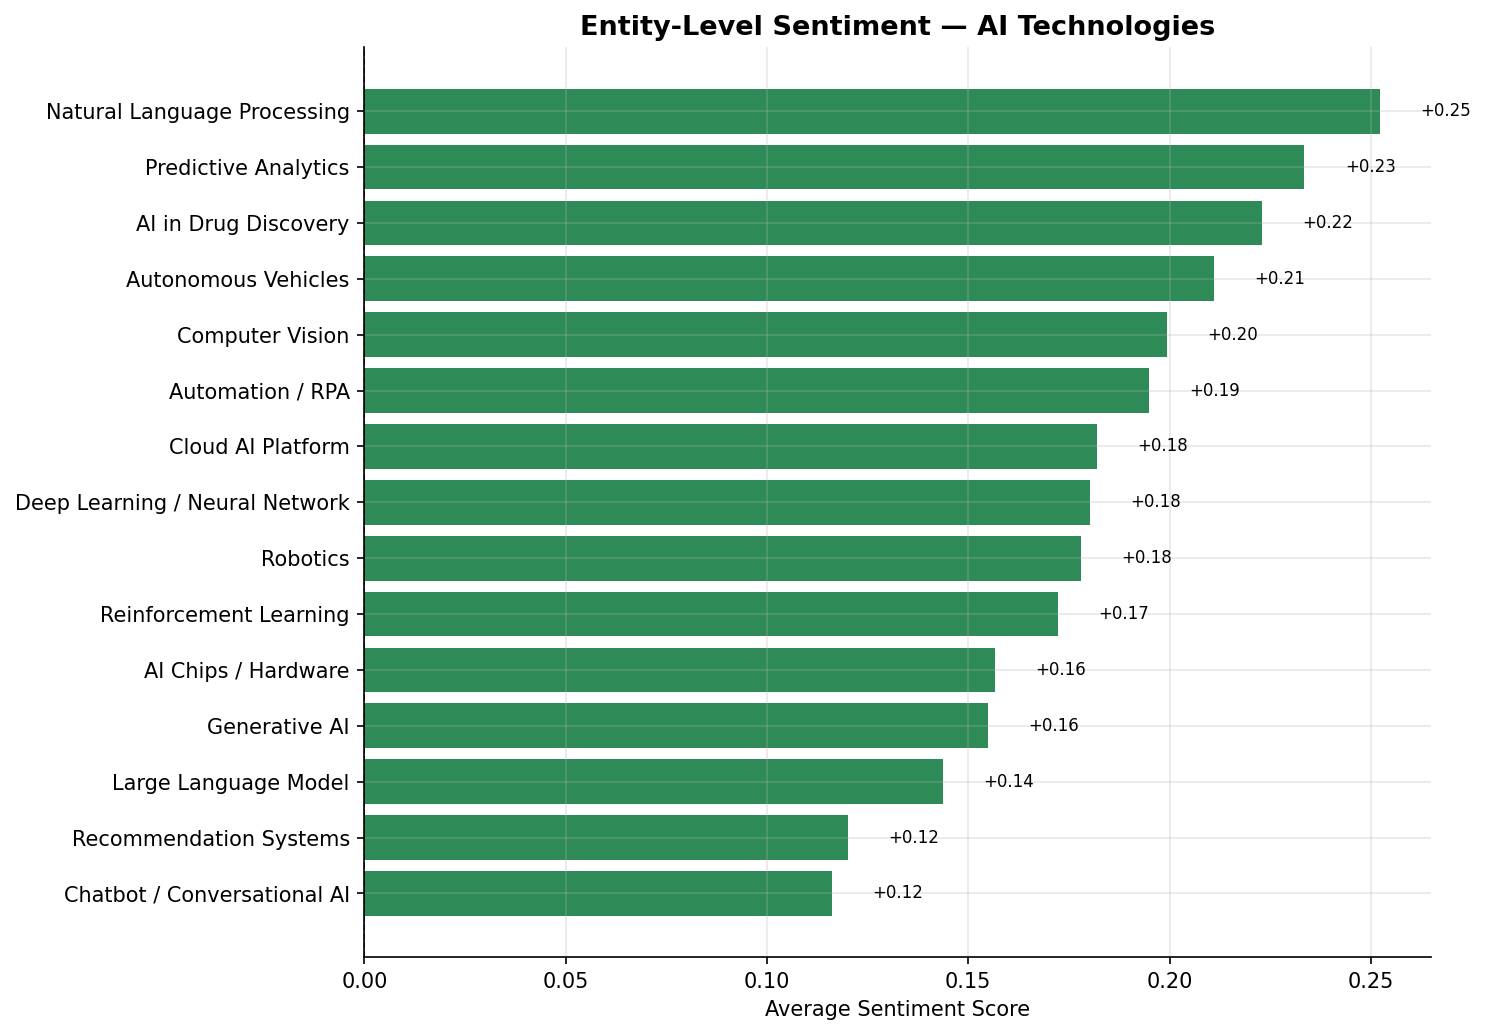

In [12]:
# ── figure: technology sentiment ──────────────────────────────────────────────
tech_plot = tech_sent.sort_values("avg_sentiment")
colors_tech = ["#d73027" if v < 0 else "#2E8B57" for v in tech_plot["avg_sentiment"]]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(tech_plot["entity"], tech_plot["avg_sentiment"], color=colors_tech, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
for bar, val in zip(bars, tech_plot["avg_sentiment"]):
    ax.text(
        val + (0.01 if val >= 0 else -0.01),
        bar.get_y() + bar.get_height()/2,
        f"{val:+.2f}", va="center",
        ha="left" if val >= 0 else "right", fontsize=8
    )
ax.set_xlabel("Average Sentiment Score")
ax.set_title("Entity-Level Sentiment — AI Technologies", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/technology_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()

## Sentiment Over Time

In [13]:
# ── parse dates with diagnostic ───────────────────────────────────────────────
DATE_COL = "date"   # change if your column name differs
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

n_bad = df[DATE_COL].isna().sum()
print(f"Rows with unparseable dates (NaT): {n_bad:,} ({n_bad/len(df)*100:.1f}%)")
print(f"Date range: {df[DATE_COL].min()} → {df[DATE_COL].max()}")

df_time = df.dropna(subset=[DATE_COL]).copy()
df_time["month"] = df_time[DATE_COL].dt.to_period("M").dt.to_timestamp()
print(f"Articles with valid dates: {len(df_time):,}")

Rows with unparseable dates (NaT): 0 (0.0%)
Date range: 2022-01-01 00:00:00 → 2026-04-29 00:00:00
Articles with valid dates: 23,237


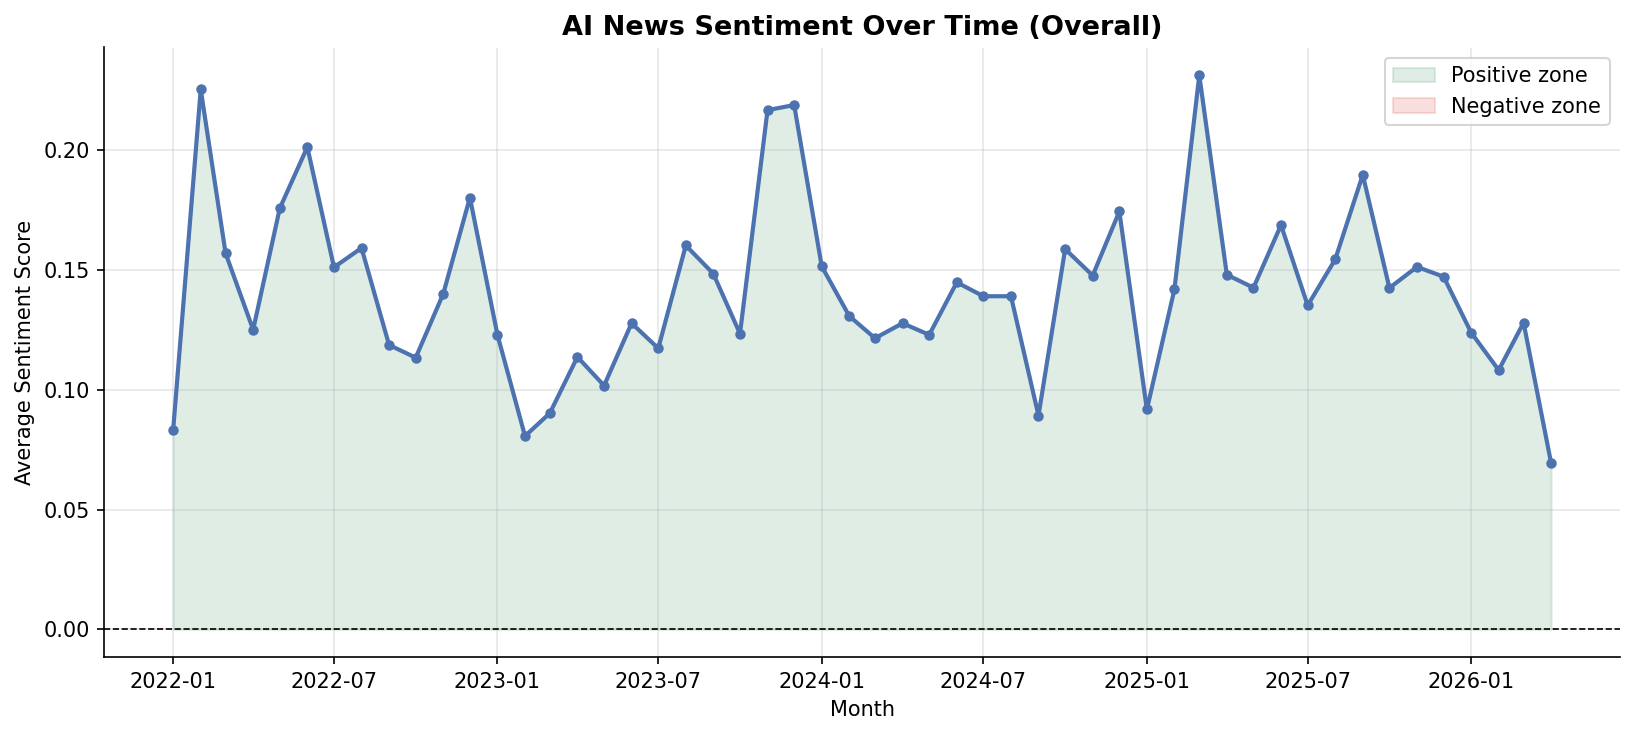

In [14]:
# ── monthly overall sentiment ─────────────────────────────────────────────────
monthly = (
    df_time.groupby("month")
    .agg(
        articles      = ("article_text", "count"),
        avg_sentiment = ("sentiment_score", "mean"),
    )
    .reset_index()
)
monthly.to_csv("outputs/monthly_sentiment.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["month"], monthly["avg_sentiment"], marker="o", linewidth=2,
        color="#4C72B0", markersize=4)
ax.fill_between(monthly["month"], monthly["avg_sentiment"], 0,
                where=(monthly["avg_sentiment"] >= 0), alpha=0.15, color="#2E8B57", label="Positive zone")
ax.fill_between(monthly["month"], monthly["avg_sentiment"], 0,
                where=(monthly["avg_sentiment"] < 0), alpha=0.15, color="#d73027", label="Negative zone")
ax.axhline(0, linestyle="--", color="black", linewidth=0.8)
ax.set_ylabel("Average Sentiment Score")
ax.set_xlabel("Month")
ax.set_title("AI News Sentiment Over Time (Overall)", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("figures/sentiment_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

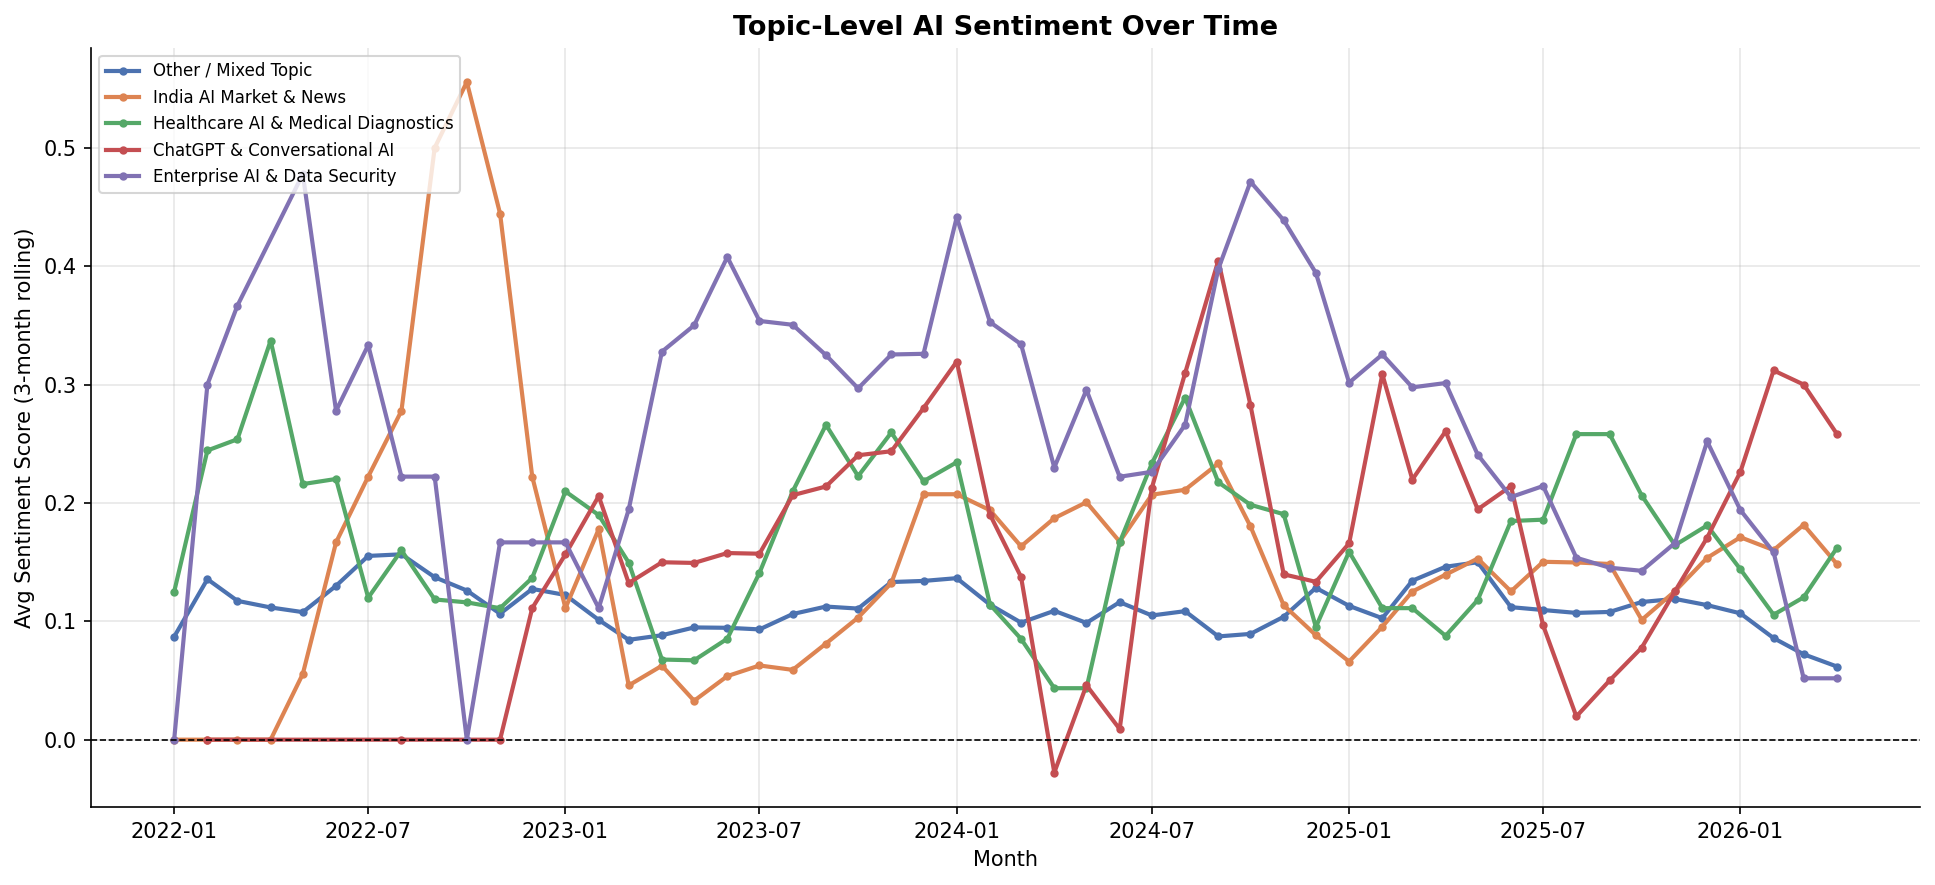

In [15]:
# ── topic-level sentiment over time ──────────────────────────────────────────
TOP_N_TOPICS = 5
top_labels = (
    df_time["topic_label"]
    .value_counts()
    .head(TOP_N_TOPICS)
    .index.tolist()
)

topic_time = (
    df_time[df_time["topic_label"].isin(top_labels)]
    .groupby(["month", "topic_label"])
    .agg(avg_sentiment=("sentiment_score", "mean"))
    .reset_index()
)
topic_time.to_csv("outputs/topic_sentiment_monthly.csv", index=False)

palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]

fig, ax = plt.subplots(figsize=(13, 6))
for i, topic in enumerate(top_labels):
    tmp = topic_time[topic_time["topic_label"] == topic]
    # smooth with 3-month rolling mean
    smoothed = tmp.set_index("month")["avg_sentiment"].rolling(3, min_periods=1).mean()
    ax.plot(smoothed.index, smoothed.values, marker="o", markersize=3,
            linewidth=2, label=topic, color=palette[i])

ax.axhline(0, linestyle="--", color="black", linewidth=0.8)
ax.set_ylabel("Avg Sentiment Score (3-month rolling)")
ax.set_xlabel("Month")
ax.set_title("Topic-Level AI Sentiment Over Time", fontsize=13, fontweight="bold")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.savefig("figures/topic_sentiment_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Task Question Answers


In [16]:
# ═══════════════════════════════════════════════════════════════════════════════
# TASK QUESTION 1
# Which industries and companies are most likely to be impacted by AI?
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("TASK Q1: Industries and companies most impacted by AI")
print("=" * 70)

# Rank industries by article volume (more coverage = more perceived impact)
industry_volume = (
    df[df["topic"] != -1]["topic_label"]
    .value_counts()
    .reset_index()
    .rename(columns={"topic_label": "industry", "count": "article_count"})
)
industry_volume["share_%"] = (industry_volume["article_count"] / industry_volume["article_count"].sum() * 100).round(1)

print("\nTop industries by media coverage volume:")
print(industry_volume.head(10).to_string(index=False))

# Top companies by mention count
top_orgs_view = pd.read_csv("outputs/top_entities.csv")
print("\nTop 15 most-mentioned companies:")
print(top_orgs_view.head(15).to_string(index=False))

TASK Q1: Industries and companies most impacted by AI

Top industries by media coverage volume:
                           industry  article_count  share_%
             India AI Market & News           1376     14.8
Healthcare AI & Medical Diagnostics           1047     11.3
        ChatGPT & Conversational AI            860      9.2
      Enterprise AI & Data Security            768      8.3
  AI Chips & Semiconductor Industry            585      6.3
                China AI & DeepSeek            449      4.8
     AI in Media & Creative Content            448      4.8
Middle East AI Adoption (UAE/Saudi)            337      3.6
             Crypto & AI Investment            323      3.5
   OpenAI & Microsoft Business News            311      3.3

Top 15 most-mentioned companies:
              organization  mentions
                    OpenAI      2896
                    Google      2696
                 Microsoft      2597
                     Apple       945
                      Met

In [17]:
# ═══════════════════════════════════════════════════════════════════════════════
# TASK QUESTION 2
# How will industries and companies be impacted — positively, negatively,
# hard-to-say — and by what means / technologies?
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("TASK Q2: How each industry is impacted (direction + mechanism)")
print("=" * 70)

# Merge volume + sentiment
impact_summary = industry_volume.merge(
    topic_sentiment[["topic_label", "avg_sentiment", "positive_share", "negative_share"]],
    left_on="industry", right_on="topic_label", how="left"
).drop(columns=["topic_label"])

# Classify impact direction
def classify_impact(avg_sent):
    if avg_sent >= 0.15:  return "Predominantly positive"
    elif avg_sent <= -0.15: return "Predominantly negative"
    else: return "Mixed / hard-to-say"

impact_summary["impact_direction"] = impact_summary["avg_sentiment"].map(classify_impact)

print(impact_summary[["industry", "article_count", "avg_sentiment", "impact_direction"]].to_string(index=False))

# Top technologies per industry (mechanism of impact)
print("\nDominant AI technologies per industry:")
tech_by_topic = pd.read_csv("outputs/tech_by_topic.csv")
print(tech_by_topic.to_string(index=False))

# Save combined impact table
impact_summary.to_csv("outputs/industry_impact_summary.csv", index=False)

TASK Q2: How each industry is impacted (direction + mechanism)
                           industry  article_count  avg_sentiment       impact_direction
             India AI Market & News           1376       0.145349    Mixed / hard-to-say
Healthcare AI & Medical Diagnostics           1047       0.170965 Predominantly positive
        ChatGPT & Conversational AI            860       0.176744 Predominantly positive
      Enterprise AI & Data Security            768       0.283854 Predominantly positive
  AI Chips & Semiconductor Industry            585       0.311111 Predominantly positive
                China AI & DeepSeek            449       0.164811 Predominantly positive
     AI in Media & Creative Content            448       0.131696    Mixed / hard-to-say
Middle East AI Adoption (UAE/Saudi)            337       0.237389 Predominantly positive
             Crypto & AI Investment            323       0.297214 Predominantly positive
   OpenAI & Microsoft Business News            

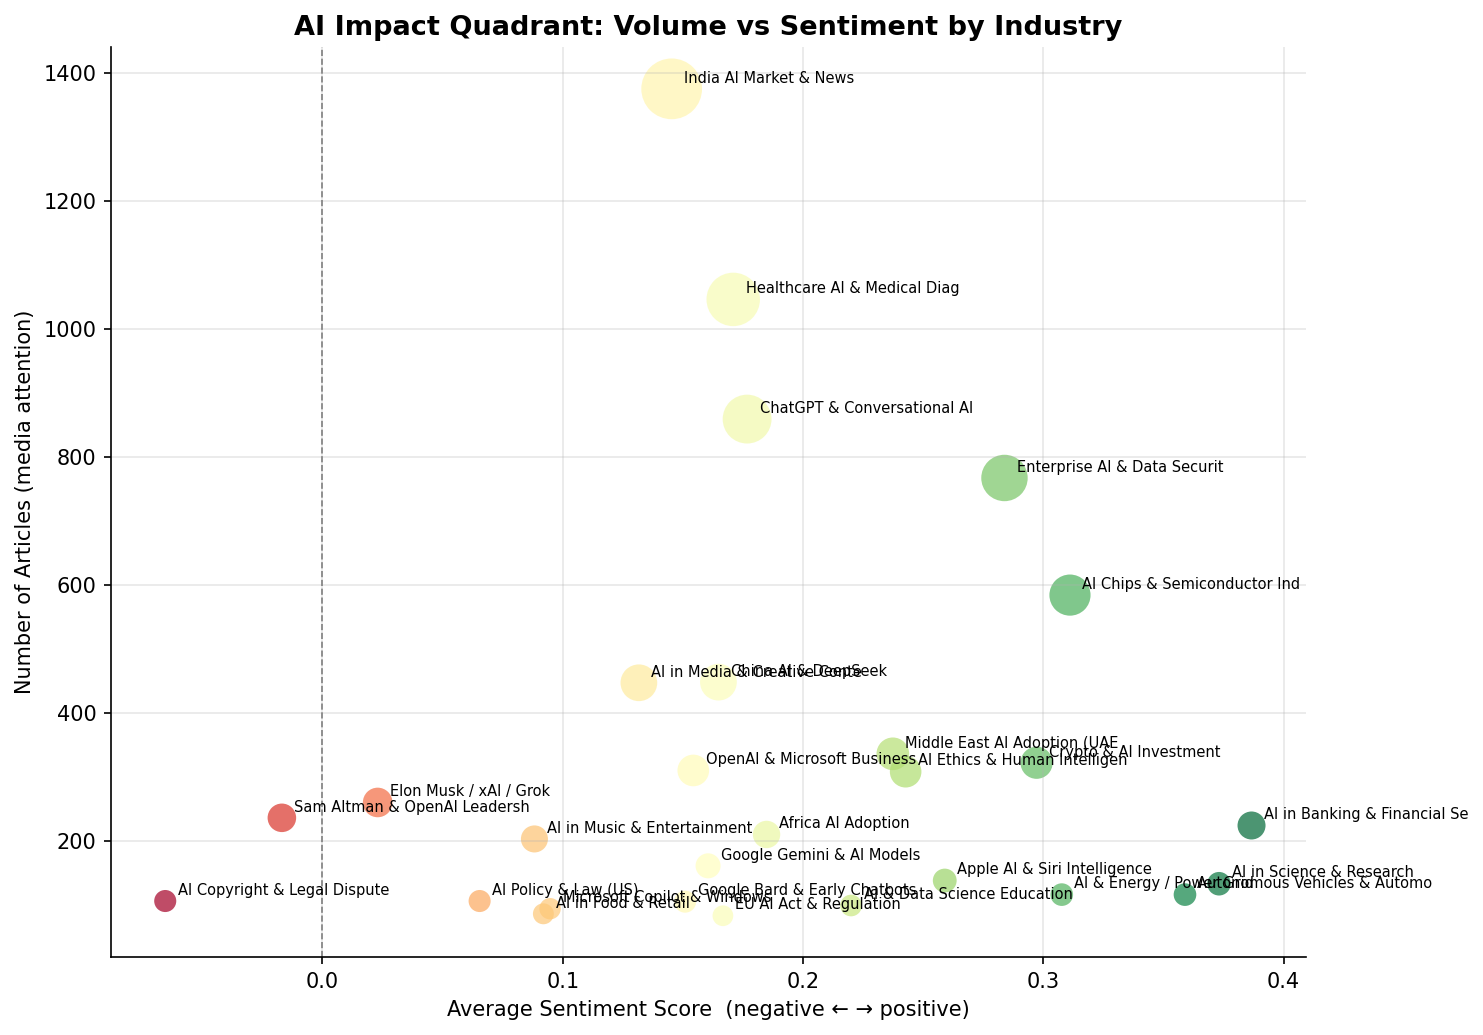

In [18]:
# ── figure: impact quadrant (volume vs sentiment) ─────────────────────────────
quad_df = impact_summary.dropna(subset=["avg_sentiment"]).copy()

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(
    quad_df["avg_sentiment"],
    quad_df["article_count"],
    s=quad_df["article_count"] / quad_df["article_count"].max() * 800 + 50,
    alpha=0.7,
    c=quad_df["avg_sentiment"],
    cmap="RdYlGn",
    edgecolors="none"
)
for _, row in quad_df.iterrows():
    ax.annotate(
        row["industry"][:28],
        (row["avg_sentiment"], row["article_count"]),
        textcoords="offset points", xytext=(6, 3), fontsize=7
    )
ax.axvline(0, linestyle="--", color="gray", linewidth=0.8)
ax.set_xlabel("Average Sentiment Score  (negative ← → positive)")
ax.set_ylabel("Number of Articles (media attention)")
ax.set_title("AI Impact Quadrant: Volume vs Sentiment by Industry",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/impact_quadrant.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
# ═══════════════════════════════════════════════════════════════════════════════
# TASK QUESTION 3
# What makes AI adoption successful or unsuccessful?
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 70)
print("TASK Q3: Factors driving AI adoption success vs friction")
print("=" * 70)

# Proxy: articles with HIGH positive sentiment — what words/topics dominate?
# Proxy: articles with HIGH negative sentiment — what words/topics dominate?

HIGH_CONF  = 0.7   # keep only confident predictions
df_conf = df[df["sentiment_confidence"] >= HIGH_CONF].copy()

pos_topics = (
    df_conf[df_conf["sentiment"] == "positive"]["topic_label"]
    .value_counts(normalize=True)
    .head(5)
    .reset_index()
)
pos_topics.columns = ["topic", "share"]
pos_topics["share"] = pos_topics["share"].map("{:.1%}".format)

neg_topics = (
    df_conf[df_conf["sentiment"] == "negative"]["topic_label"]
    .value_counts(normalize=True)
    .head(5)
    .reset_index()
)
neg_topics.columns = ["topic", "share"]
neg_topics["share"] = neg_topics["share"].map("{:.1%}".format)

print("\nTopics concentrated in POSITIVE articles (success signals):")
print(pos_topics.to_string(index=False))

print("\nTopics concentrated in NEGATIVE articles (friction signals):")
print(neg_topics.to_string(index=False))

# Adoption success/failure signal via technology sentiment
print("\nTechnologies with highest positive sentiment (facilitating adoption):")
print(tech_sent.sort_values("avg_sentiment", ascending=False).head(5)[
    ["entity", "articles", "avg_sentiment", "positive_share"]
].to_string(index=False))

print("\nTechnologies with most negative sentiment (adoption friction):")
print(tech_sent.sort_values("avg_sentiment").head(5)[
    ["entity", "articles", "avg_sentiment", "negative_share"]
].to_string(index=False))

TASK Q3: Factors driving AI adoption success vs friction

Topics concentrated in POSITIVE articles (success signals):
                              topic share
                Other / Mixed Topic 46.9%
      Enterprise AI & Data Security  6.4%
             India AI Market & News  6.2%
  AI Chips & Semiconductor Industry  5.7%
Healthcare AI & Medical Diagnostics  4.9%

Topics concentrated in NEGATIVE articles (friction signals):
                            topic share
              Other / Mixed Topic 55.0%
              China AI & DeepSeek  6.2%
      ChatGPT & Conversational AI  5.6%
           India AI Market & News  5.6%
AI Chips & Semiconductor Industry  4.6%

Technologies with highest positive sentiment (facilitating adoption):
                     entity  articles  avg_sentiment  positive_share
Natural Language Processing      1114       0.252244        0.256732
       Predictive Analytics       955       0.233508        0.250262
       AI in Drug Discovery       341       0.2228

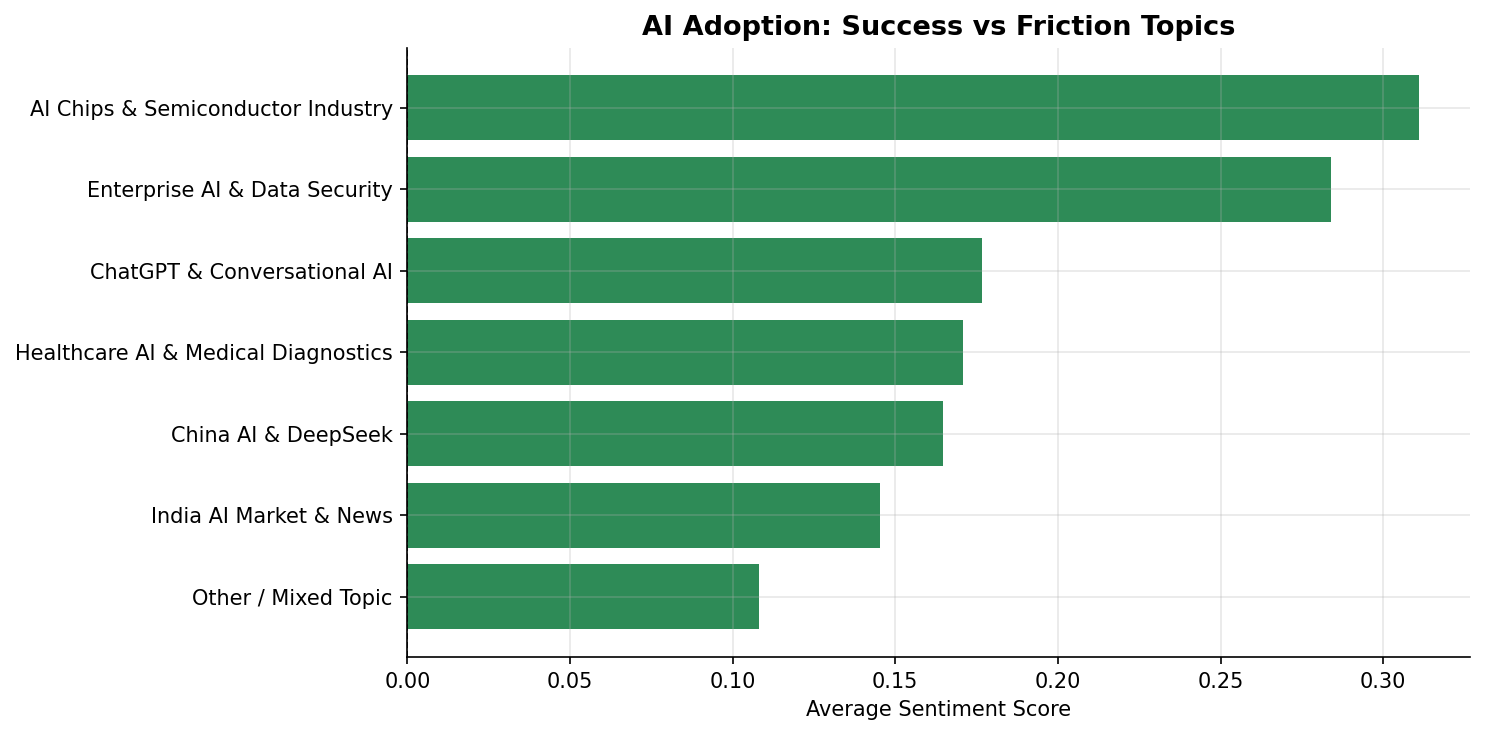

In [20]:
# ── figure: Q3 success vs friction topic comparison ──────────────────────────
success_topics = pos_topics["topic"].tolist()[:5]
friction_topics = neg_topics["topic"].tolist()[:5]
all_q3_topics = list(set(success_topics + friction_topics))

q3_df = topic_sentiment[topic_sentiment["topic_label"].isin(all_q3_topics)].copy()
q3_df = q3_df.sort_values("avg_sentiment")

bar_colors = ["#2E8B57" if v > 0 else "#d73027" for v in q3_df["avg_sentiment"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(q3_df["topic_label"], q3_df["avg_sentiment"], color=bar_colors, edgecolor="none")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Average Sentiment Score")
ax.set_title("AI Adoption: Success vs Friction Topics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/adoption_success_friction.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
# ── final summary printout ────────────────────────────────────────────────────
print("\n" + "═" * 70)
print("ANALYSIS COMPLETE — key output files:")
print("═" * 70)
outputs = [
    ("outputs/cleaning_summary.csv",        "Data cleaning funnel"),
    ("outputs/topic_keywords.csv",          "BERTopic keyword table"),
    ("outputs/topic_label_mapping.csv",     "Manual topic → industry mapping"),
    ("outputs/topic_sentiment.csv",         "Topic-level sentiment"),
    ("outputs/entity_sentiment.csv",        "Org-level sentiment"),
    ("outputs/technology_sentiment.csv",    "Technology-level sentiment"),
    ("outputs/monthly_sentiment.csv",       "Monthly overall sentiment"),
    ("outputs/topic_sentiment_monthly.csv", "Monthly per-topic sentiment"),
    ("outputs/industry_impact_summary.csv", "Q1+Q2 combined impact table"),
]
for path, desc in outputs:
    exists = "✓" if Path(path).exists() else "✗ MISSING"
    print(f"  {exists}  {path:50s} {desc}")


══════════════════════════════════════════════════════════════════════
ANALYSIS COMPLETE — key output files:
══════════════════════════════════════════════════════════════════════
  ✓  outputs/cleaning_summary.csv                       Data cleaning funnel
  ✓  outputs/topic_keywords.csv                         BERTopic keyword table
  ✓  outputs/topic_label_mapping.csv                    Manual topic → industry mapping
  ✓  outputs/topic_sentiment.csv                        Topic-level sentiment
  ✓  outputs/entity_sentiment.csv                       Org-level sentiment
  ✓  outputs/technology_sentiment.csv                   Technology-level sentiment
  ✓  outputs/monthly_sentiment.csv                      Monthly overall sentiment
  ✓  outputs/topic_sentiment_monthly.csv                Monthly per-topic sentiment
  ✓  outputs/industry_impact_summary.csv                Q1+Q2 combined impact table
